# 첫번째 테스트

Using device: cuda
Step 1: Loading and preprocessing data...
Total unique nodes: 213
Total classes: 4 -> ['flowers' 'fruits' 'herbs' 'vegetables']
Edge types: ['avoid' 'helped_by' 'helps']

Step 2: Building the graph data object...
Graph data object created and moved to device.
Data(x=[213], edge_index=[2, 1004], edge_attr=[1004, 3], y=[213], train_mask=[213], val_mask=[213], test_mask=[213])

Step 3: Defining the Advanced GNN Model...
Model created:
AdvancedGAT(
  (embedding): Embedding(213, 128)
  (convs): ModuleList(
    (0): ResidualGATBlock(
      (conv): GATv2Conv(128, 128, heads=4)
      (res_lin): Linear(in_features=128, out_features=512, bias=True)
    )
    (1): ResidualGATBlock(
      (conv): GATv2Conv(512, 128, heads=4)
      (res_lin): Identity()
    )
    (2): ResidualGATBlock(
      (conv): GATv2Conv(512, 128, heads=4)
      (res_lin): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (jk): JumpingKnowledge(cat)
  (final_lin): Linear(in_features=1152, out_

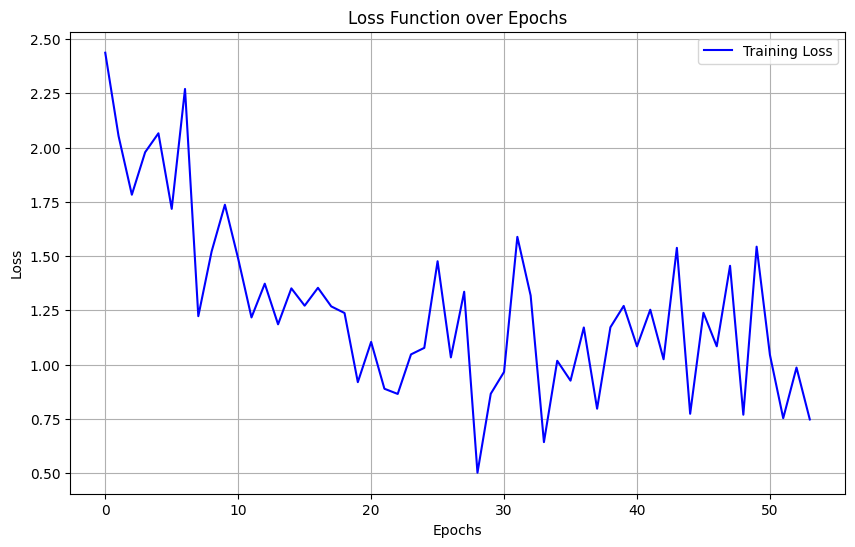


--- Final Model Performance (based on best validation accuracy) ---
Final Train Accuracy: 1.0000
Final Validation Accuracy: 0.7368
Final Test Accuracy: 0.8333

Step 7: Generating predictions for the test file...

--- Predictions for test.csv ---
         src predicted_class
0      beets    [vegetables]
1  brassicas         [herbs]
2    carrots    [vegetables]
3       dill         [herbs]
4    legumes    [vegetables]
5   broccoli    [vegetables]


In [1]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F
from torch.nn import Module, ModuleList, Linear, Embedding
!pip install torch-geometric
from torch_geometric.nn import GATv2Conv, JumpingKnowledge
from torch_geometric.data import Data
import matplotlib.pyplot as plt

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==============================================================================
# 1. 데이터 로드 및 전처리
# ==============================================================================
print("Step 1: Loading and preprocessing data...")

# 데이터 로드
try:
    train_df = pd.read_csv('companion_plants.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Error: 'companion_plants.csv' or 'test.csv' not found.")
    print("Please upload the files to your Colab session.")
    # This will stop the script if files are not found.
    exit()


# 데이터 정제 및 표준화 함수
def preprocess_df(df):
    df_copy = df.copy()
    # 모든 문자열 열에 대해 소문자 변환 및 공백 제거
    for col in ['src', 'dst', 'Link']:
        if df_copy[col].dtype == 'object':
            df_copy[col] = df_copy[col].str.lower().str.strip()

    # 동의어 및 오타 처리
    synonym_map = {
        'maize': 'corn',
        'aubergine': 'eggplant',
        'chamomille': 'chamomile',
        'corier': 'coriander',
        'avvoid': 'avoid' # test.csv의 오타 수정
    }
    df_copy.replace(synonym_map, inplace=True)
    return df_copy

train_df = preprocess_df(train_df)
test_df = preprocess_df(test_df)

# 전체 노드(식물) 목록 생성
all_nodes = pd.concat([train_df['src'], train_df['dst'], test_df['src'], test_df['dst']]).unique()
node_encoder = LabelEncoder()
node_encoder.fit(all_nodes)
num_nodes = len(node_encoder.classes_)

# 레이블 인코딩
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
num_classes = len(label_encoder.classes_)

# 관계(Link) 타입 인코딩
link_encoder = LabelEncoder()
train_df['link_encoded'] = link_encoder.fit_transform(train_df['Link'])
test_df['link_encoded'] = link_encoder.transform(test_df['Link']) # train에서 학습된 인코더 사용
num_edge_features = len(link_encoder.classes_)

print(f"Total unique nodes: {num_nodes}")
print(f"Total classes: {num_classes} -> {label_encoder.classes_}")
print(f"Edge types: {link_encoder.classes_}")


# ==============================================================================
# 2. 그래프 데이터 객체 생성
# ==============================================================================
print("\nStep 2: Building the graph data object...")

# 노드 ID 매핑
train_df['src_id'] = node_encoder.transform(train_df['src'])
train_df['dst_id'] = node_encoder.transform(train_df['dst'])
test_df['src_id'] = node_encoder.transform(test_df['src'])
test_df['dst_id'] = node_encoder.transform(test_df['dst'])

# 엣지 인덱스 생성
edge_index_train = torch.tensor(train_df[['src_id', 'dst_id']].values.T, dtype=torch.long)
edge_index_test = torch.tensor(test_df[['src_id', 'dst_id']].values.T, dtype=torch.long)
edge_index = torch.cat([edge_index_train, edge_index_test], dim=1)

# 엣지 속성 생성 (One-hot encoding)
edge_attr_train = F.one_hot(torch.tensor(train_df['link_encoded']), num_classes=num_edge_features).float()
edge_attr_test = F.one_hot(torch.tensor(test_df['link_encoded']), num_classes=num_edge_features).float()
edge_attr = torch.cat([edge_attr_train, edge_attr_test], dim=0)

# 레이블(y) 및 노드별 ID(x) 생성
# src 노드와 레이블을 매핑
node_labels = {}
for _, row in train_df.iterrows():
    node_labels[row['src_id']] = row['label_encoded']

y = torch.full((num_nodes,), -1, dtype=torch.long) # -1 for unlabeled nodes
for node_id, label in node_labels.items():
    y[node_id] = label

# 노드 특성은 학습 가능한 임베딩을 위해 노드 인덱스 자체를 사용
x = torch.arange(num_nodes, dtype=torch.long)

# 훈련, 검증, 테스트 마스크 생성
train_val_nodes = torch.tensor(list(node_labels.keys()), dtype=torch.long)
test_nodes = torch.tensor(test_df['src_id'].unique(), dtype=torch.long)

# train_val_nodes를 훈련 및 검증 세트로 분할
train_nodes, val_nodes = train_test_split(train_val_nodes, test_size=0.2, random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_nodes] = True
val_mask[val_nodes] = True
test_mask[test_nodes] = True

# 최종 PyG 데이터 객체
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

data = data.to(device)
print("Graph data object created and moved to device.")
print(data)


# ==============================================================================
# 3. 고급 GNN 모델 정의 (GATv2 + Residual + Jumping Knowledge)
# ==============================================================================
print("\nStep 3: Defining the Advanced GNN Model...")

########### 수정가능 부분 (하이퍼파라메타)
EMBEDDING_DIM = 128
HIDDEN_CHANNELS = 128
NUM_LAYERS = 3
HEADS = 4
DROPOUT = 0.6
LEARNING_RATE = 0.005
WEIGHT_DECAY = 5e-4
EPOCHS = 300
EARLY_STOPPING_PATIENCE = 50
JK_MODE = 'cat' # 'cat', 'max', 'lstm'
########

class ResidualGATBlock(Module):
    def __init__(self, in_channels, out_channels, heads, dropout, edge_dim, concat=True):
        super().__init__()
        self.concat = concat
        self.conv = GATv2Conv(in_channels, out_channels, heads=heads, dropout=dropout,
                              edge_dim=edge_dim, concat=concat)

        # 잔차 연결을 위한 차원 맞춤용 Linear 레이어
        if in_channels!= out_channels * (heads if concat else 1):
            self.res_lin = Linear(in_channels, out_channels * (heads if concat else 1))
        else:
            self.res_lin = torch.nn.Identity()

    def forward(self, x, edge_index, edge_attr):
        identity = self.res_lin(x)
        out = self.conv(x, edge_index, edge_attr)
        out = F.elu(identity + out) # 잔차 연결
        return out

#######수정가능 부분(내가 만든 모델)
class AdvancedGAT(Module):
    def __init__(self, num_nodes, embedding_dim, hidden_channels, out_channels,
                 num_layers, heads, dropout, jk_mode, edge_dim):
        super().__init__()
        self.embedding = Embedding(num_nodes, embedding_dim)

        self.convs = ModuleList()
        # Input layer
        self.convs.append(ResidualGATBlock(embedding_dim, hidden_channels, heads, dropout, edge_dim))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(ResidualGATBlock(hidden_channels * heads, hidden_channels, heads, dropout, edge_dim))

        # Last GNN layer (no concatenation)
        # The last layer outputs to JK, so it doesn't need to match the *next* layer's input,
        # but its output dimension (hidden_channels for concat=False) should be suitable for JK.
        self.convs.append(ResidualGATBlock(hidden_channels * heads, hidden_channels, heads, dropout, edge_dim, concat=False))


        self.jk = JumpingKnowledge(jk_mode, channels=hidden_channels, num_layers=num_layers)

        if jk_mode == 'cat':
            # When jk_mode is 'cat', JK concatenates the output of *each* layer.
            # The output dimension of each GATv2Conv with concat=True is hidden_channels * heads.
            # The output dimension of the last GATv2Conv with concat=False is hidden_channels.
            # So, the total concatenated dimension is (num_layers - 1) * (hidden_channels * heads) + hidden_channels
            final_linear_input_dim = (num_layers - 1) * (hidden_channels * heads) + hidden_channels
            self.final_lin = Linear(final_linear_input_dim, out_channels)
        else: # 'max' or 'lstm'
            self.final_lin = Linear(hidden_channels, out_channels)


        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr):
        x = self.embedding(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        layer_outputs = []
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = F.dropout(x, p=self.dropout, training=self.training)
            # JK-Net은 각 GNN 레이어의 최종 출력을 집계합니다.
            # ResidualGATBlock의 출력이 다음 레이어의 입력이 되므로,
            # 여기서는 각 블록의 출력을 저장합니다.
            layer_outputs.append(x)


        jk_output = self.jk(layer_outputs)
        final_output = self.final_lin(jk_output)

        return F.log_softmax(final_output, dim=1)

model = AdvancedGAT(
    num_nodes=num_nodes,
    embedding_dim=EMBEDDING_DIM,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=num_classes,
    num_layers=NUM_LAYERS,
    heads=HEADS,
    dropout=DROPOUT,
    jk_mode=JK_MODE,
    edge_dim=num_edge_features
).to(device)

print("Model created:")
print(model)


# ==============================================================================
# 4. 훈련 및 평가 루프
# ==============================================================================
print("\nStep 4: Setting up training and evaluation...")

############# 수정가능 부분 (최적화부분)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_function = torch.nn.CrossEntropyLoss()
#############

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)
    loss = loss_function(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test():
    model.eval()
    out = model(data.x, data.edge_index, data.edge_attr)
    pred = out.argmax(dim=1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask] == data.y[mask]
        # 테스트 마스크의 경우, 레이블이 없는 노드가 있을 수 있으므로 유효한 노드만 계산
        valid_nodes = data.y[mask]!= -1
        accs.append(int((correct & valid_nodes).sum()) / int(valid_nodes.sum()))

    return accs


# ==============================================================================
# 5. 모델 훈련 실행
# ==============================================================================
print("\nStep 5: Starting model training...")

best_val_acc = 0
patience_counter = 0
best_model_state = None
losses = []

for epoch in range(1, EPOCHS + 1):
    loss = train()
    losses.append(loss)
    train_acc, val_acc, test_acc = test()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, '
              f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}!")
        break

print("Training finished.")


# ==============================================================================
# 6. 결과 시각화 및 평가
# ==============================================================================
print("\nStep 6: Visualizing results and final evaluation...")

# Loss Function 그래프 출력
plt.figure(figsize=(10, 6))
plt.plot(losses, label='Training Loss', color='blue')
plt.title('Loss Function over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 가장 좋았던 모델로 최종 평가
model.load_state_dict(best_model_state)
final_train_acc, final_val_acc, final_test_acc = test()
print("\n--- Final Model Performance (based on best validation accuracy) ---")
print(f'Final Train Accuracy: {final_train_acc:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
print(f'Final Test Accuracy: {final_test_acc:.4f}')


# ==============================================================================
# 7. 테스트 파일에 대한 최종 예측 출력
# ==============================================================================
print("\nStep 7: Generating predictions for the test file...")

model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index, data.edge_attr)
    pred = out.argmax(dim=1)

test_src_nodes = test_df['src'].unique()
test_src_ids = node_encoder.transform(test_src_nodes)

predictions = []
for node_name, node_id in zip(test_src_nodes, test_src_ids):
    predicted_label_id = pred[node_id].item()
    predicted_label_name = label_encoder.inverse_transform([predicted_label_id])
    predictions.append({'src': node_name, 'predicted_class': predicted_label_name})

prediction_df = pd.DataFrame(predictions)
print("\n--- Predictions for test.csv ---")
print(prediction_df.to_string())

# 두번째 테스트( 초기화 후 진행)

In [2]:
!pip install torch-geometric

Using device: cuda
Step 1: Loading and preprocessing data...
Total unique nodes: 213
Total classes: 4 -> ['flowers' 'fruits' 'herbs' 'vegetables']
Edge types: ['avoid' 'helped_by' 'helps']

Step 2: Building the graph data object...
Graph data object created and moved to device.
Data(x=[213], edge_index=[2, 1004], edge_attr=[1004, 3], y=[213], train_mask=[213], val_mask=[213], test_mask=[213])

Step 3: Defining the Advanced GNN Model...
Model created:
AdvancedGAT(
  (embedding): Embedding(213, 128)
  (convs): ModuleList(
    (0): ResidualGATBlock(
      (conv): GATv2Conv(128, 128, heads=4)
      (res_lin): Linear(in_features=128, out_features=512, bias=True)
    )
    (1): ResidualGATBlock(
      (conv): GATv2Conv(512, 128, heads=4)
      (res_lin): Identity()
    )
    (2): ResidualGATBlock(
      (conv): GATv2Conv(512, 128, heads=4)
      (res_lin): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (jk): JumpingKnowledge(cat)
  (final_lin): Linear(in_features=1152, out_

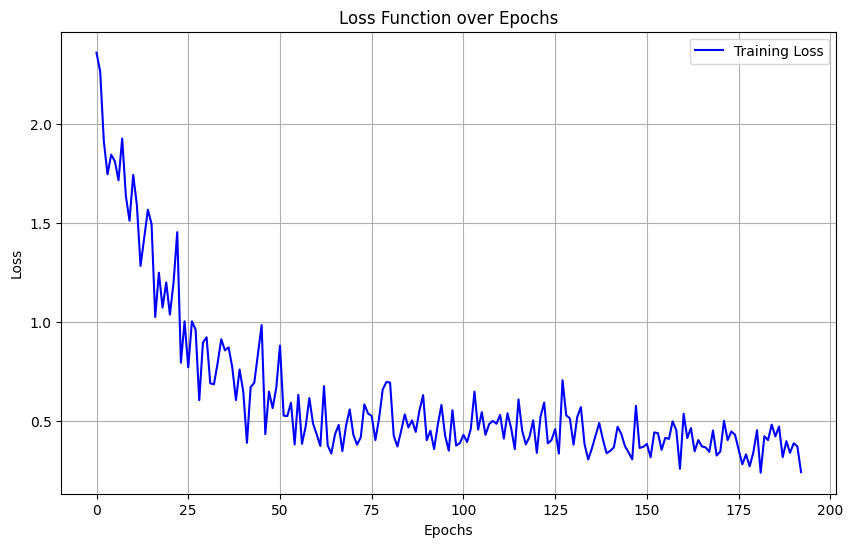


--- Final Model Performance (based on best validation accuracy) ---
Final Train Accuracy: 0.9868
Final Validation Accuracy: 0.7368
Final Test Accuracy: 0.8333

Step 7: Generating predictions for the test file...

--- Predictions for test.csv ---
         src predicted_class
0      beets    [vegetables]
1  brassicas         [herbs]
2    carrots    [vegetables]
3       dill         [herbs]
4    legumes    [vegetables]
5   broccoli    [vegetables]


In [3]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F
from torch.nn import Module, ModuleList, Linear, Embedding
from torch_geometric.nn import GATv2Conv, JumpingKnowledge
from torch_geometric.data import Data
import matplotlib.pyplot as plt
# --- 수정/추가된 부분 ---
from torch.optim.lr_scheduler import ReduceLROnPlateau

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==============================================================================
# 1. 데이터 로드 및 전처리 (이전과 동일)
# ==============================================================================
print("Step 1: Loading and preprocessing data...")

# 데이터 로드
try:
    train_df = pd.read_csv('companion_plants.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Error: 'companion_plants.csv' or 'test.csv' not found.")
    print("Please upload the files to your Colab session.")
    exit()

def preprocess_df(df):
    df_copy = df.copy()
    for col in ['src', 'dst', 'Link']:
        if df_copy[col].dtype == 'object':
            df_copy[col] = df_copy[col].str.lower().str.strip()
    synonym_map = {
        'maize': 'corn', 'aubergine': 'eggplant', 'chamomille': 'chamomile',
        'corier': 'coriander', 'avvoid': 'avoid'
    }
    df_copy.replace(synonym_map, inplace=True)
    return df_copy

train_df = preprocess_df(train_df)
test_df = preprocess_df(test_df)

all_nodes = pd.concat([train_df['src'], train_df['dst'], test_df['src'], test_df['dst']]).unique()
node_encoder = LabelEncoder()
node_encoder.fit(all_nodes)
num_nodes = len(node_encoder.classes_)

label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
num_classes = len(label_encoder.classes_)

link_encoder = LabelEncoder()
train_df['link_encoded'] = link_encoder.fit_transform(train_df['Link'])
test_df['link_encoded'] = link_encoder.transform(test_df['Link'])
num_edge_features = len(link_encoder.classes_)

print(f"Total unique nodes: {num_nodes}")
print(f"Total classes: {num_classes} -> {label_encoder.classes_}")
print(f"Edge types: {link_encoder.classes_}")


# ==============================================================================
# 2. 그래프 데이터 객체 생성 (이전과 동일)
# ==============================================================================
print("\nStep 2: Building the graph data object...")

train_df['src_id'] = node_encoder.transform(train_df['src'])
train_df['dst_id'] = node_encoder.transform(train_df['dst'])
test_df['src_id'] = node_encoder.transform(test_df['src'])
test_df['dst_id'] = node_encoder.transform(test_df['dst'])

edge_index_train = torch.tensor(train_df[['src_id', 'dst_id']].values.T, dtype=torch.long)
edge_index_test = torch.tensor(test_df[['src_id', 'dst_id']].values.T, dtype=torch.long)
edge_index = torch.cat([edge_index_train, edge_index_test], dim=1)

edge_attr_train = F.one_hot(torch.tensor(train_df['link_encoded']), num_classes=num_edge_features).float()
edge_attr_test = F.one_hot(torch.tensor(test_df['link_encoded']), num_classes=num_edge_features).float()
edge_attr = torch.cat([edge_attr_train, edge_attr_test], dim=0)

node_labels = {}
for _, row in train_df.iterrows():
    node_labels[row['src_id']] = row['label_encoded']

y = torch.full((num_nodes,), -1, dtype=torch.long)
for node_id, label in node_labels.items():
    y[node_id] = label

x = torch.arange(num_nodes, dtype=torch.long)

train_val_nodes = torch.tensor(list(node_labels.keys()), dtype=torch.long)
test_nodes = torch.tensor(test_df['src_id'].unique(), dtype=torch.long)

train_nodes, val_nodes = train_test_split(train_val_nodes, test_size=0.2, random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_nodes] = True
val_mask[val_nodes] = True
test_mask[test_nodes] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

data = data.to(device)
print("Graph data object created and moved to device.")
print(data)


# ==============================================================================
# 3. 고급 GNN 모델 정의 (이전과 동일)
# ==============================================================================
print("\nStep 3: Defining the Advanced GNN Model...")

########### 수정가능 부분 (하이퍼파라메타) --- 여기가 수정되었습니다 ---
EMBEDDING_DIM = 128
HIDDEN_CHANNELS = 128
NUM_LAYERS = 3
HEADS = 4
DROPOUT = 0.6
LEARNING_RATE = 0.001       # 학습률 하향 조정 (0.005 -> 0.001)
WEIGHT_DECAY = 1e-3         # 가중치 감쇠 상향 조정 (5e-4 -> 1e-3)
EPOCHS = 1000               # 최대 에폭 증가 (300 -> 1000)
EARLY_STOPPING_PATIENCE = 100 # 조기 종료 인내심 증가 (50 -> 100)
JK_MODE = 'cat'
########

class ResidualGATBlock(Module):
    def __init__(self, in_channels, out_channels, heads, dropout, edge_dim, concat=True):
        super().__init__()
        self.concat = concat
        self.conv = GATv2Conv(in_channels, out_channels, heads=heads, dropout=dropout,
                              edge_dim=edge_dim, concat=concat)
        if in_channels!= out_channels * (heads if concat else 1):
            self.res_lin = Linear(in_channels, out_channels * (heads if concat else 1))
        else:
            self.res_lin = torch.nn.Identity()

    def forward(self, x, edge_index, edge_attr):
        identity = self.res_lin(x)
        out = self.conv(x, edge_index, edge_attr)
        out = F.elu(identity + out)
        return out

#######수정가능 부분(내가 만든 모델)
class AdvancedGAT(Module):
    def __init__(self, num_nodes, embedding_dim, hidden_channels, out_channels,
                 num_layers, heads, dropout, jk_mode, edge_dim):
        super().__init__()
        self.embedding = Embedding(num_nodes, embedding_dim)
        self.convs = ModuleList()
        self.convs.append(ResidualGATBlock(embedding_dim, hidden_channels, heads, dropout, edge_dim))
        for _ in range(num_layers - 2):
            self.convs.append(ResidualGATBlock(hidden_channels * heads, hidden_channels, heads, dropout, edge_dim))
        self.convs.append(ResidualGATBlock(hidden_channels * heads, hidden_channels, heads, dropout, edge_dim, concat=False))
        self.jk = JumpingKnowledge(jk_mode, channels=hidden_channels, num_layers=num_layers)
        if jk_mode == 'cat':
            # Corrected input dimension for the final linear layer
            # It concatenates the output of all layers.
            # The first layer outputs hidden_channels * heads (if concat=True).
            # The intermediate layers output hidden_channels * heads (if concat=True).
            # The last layer outputs hidden_channels (if concat=False).
            # Total concatenated dimension: (num_layers - 1) * (hidden_channels * heads) + hidden_channels
            final_linear_input_dim = (num_layers - 1) * (hidden_channels * heads) + hidden_channels
            self.final_lin = Linear(final_linear_input_dim, out_channels)
        else:
            self.final_lin = Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr):
        x = self.embedding(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        layer_outputs = [] # Initialized as an empty list
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = F.dropout(x, p=self.dropout, training=self.training)
            layer_outputs.append(x)
        jk_output = self.jk(layer_outputs)
        final_output = self.final_lin(jk_output)
        return F.log_softmax(final_output, dim=1)

model = AdvancedGAT(
    num_nodes=num_nodes, embedding_dim=EMBEDDING_DIM, hidden_channels=HIDDEN_CHANNELS,
    out_channels=num_classes, num_layers=NUM_LAYERS, heads=HEADS, dropout=DROPOUT,
    jk_mode=JK_MODE, edge_dim=num_edge_features
).to(device)

print("Model created:")
print(model)


# ==============================================================================
# 4. 훈련 및 평가 루프
# ==============================================================================
print("\nStep 4: Setting up training and evaluation...")

############# 수정가능 부분 (최적화부분) --- 여기가 수정되었습니다 ---
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_function = torch.nn.CrossEntropyLoss()
# --- 학습률 스케줄러 추가 ---
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20) # Removed verbose=True
#############

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)
    loss = loss_function(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test():
    model.eval()
    out = model(data.x, data.edge_index, data.edge_attr)
    pred = out.argmax(dim=1)

    # --- 수정/추가된 부분: 검증 손실(val_loss)도 반환하도록 수정 ---
    val_loss = loss_function(out[data.val_mask], data.y[data.val_mask]).item()

    accs = [] # Initialized as an empty list
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask] == data.y[mask]
        valid_nodes = data.y[mask]!= -1
        accs.append(int((correct & valid_nodes).sum()) / int(valid_nodes.sum()))

    return accs, val_loss


# ==============================================================================
# 5. 모델 훈련 실행 --- 여기가 수정되었습니다 ---
# ==============================================================================
print("\nStep 5: Starting model training...")

best_val_acc = 0
patience_counter = 0
best_model_state = None
losses = [] # Initialized as an empty list

for epoch in range(1, EPOCHS + 1):
    loss = train()
    losses.append(loss)
    (train_acc, val_acc, test_acc), val_loss = test()

    # --- 스케줄러 업데이트 로직 추가 ---
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_state = model.state_dict()
        print(f'---> New best model found at epoch {epoch:03d} with Val Acc: {val_acc:.4f}')
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Train: {train_acc:.4f}, '
              f'Val: {val_acc:.4f}, Test: {test_acc:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}') # Corrected LR access

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}!")
        break

print("Training finished.")


# ==============================================================================
# 6. 결과 시각화 및 평가 (이 이전과 동일)
# ==============================================================================
print("\nStep 6: Visualizing results and final evaluation...")

plt.figure(figsize=(10, 6))
plt.plot(losses, label='Training Loss', color='blue')
plt.title('Loss Function over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

model.load_state_dict(best_model_state)
(final_train_acc, final_val_acc, final_test_acc), _ = test()
print("\n--- Final Model Performance (based on best validation accuracy) ---")
print(f'Final Train Accuracy: {final_train_acc:.4f}')
print(f'Final Validation Accuracy: {final_val_acc:.4f}')
print(f'Final Test Accuracy: {final_test_acc:.4f}')


# ==============================================================================
# 7. 테스트 파일에 대한 최종 예측 출력 (이전과 동일)
# ==============================================================================
print("\nStep 7: Generating predictions for the test file...")

model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index, data.edge_attr)
    pred = out.argmax(dim=1)

test_src_nodes = test_df['src'].unique()
test_src_ids = node_encoder.transform(test_src_nodes)

predictions = [] # Initialized as an empty list
for node_name, node_id in zip(test_src_nodes, test_src_ids):
    predicted_label_id = pred[node_id].item()
    predicted_label_name = label_encoder.inverse_transform([predicted_label_id])
    predictions.append({'src': node_name, 'predicted_class': predicted_label_name})

prediction_df = pd.DataFrame(predictions)
print("\n--- Predictions for test.csv ---")
print(prediction_df.to_string())

이로써 테스트는 종료한다.
우선, 데이터가 적었기 떄문에 학습이 나쁘지 않게 되었다고 생각한다. 그러나 이 데이터가 적은 것이 예측성능에 있어서 절대적인지, 믿을만 한지는 의심스럽다.
여러가지 AI를 써보았지만, 최신논문에선 GAT모델보다 개선된 GAT2모델을 사용한다고 한다. 이에 대해서 조금 찾아보게 되었고 아직도 이쪽 분야는 계속 연구중이고 정확한 답이없다는 것을 깨달았다.
이분야에 들어가려면 매우 많은 공부와 여러가지 정보를 걸러낼 수 있는 통찰력이 매우 중요할 것 같다.